<div style="background:linear-gradient(135deg,#0A1A2F 0%,#123B55 55%,#15757B 100%);padding:36px 32px;border-radius:14px;color:white;font-family:Arial">
  <div style="font-size:12px;letter-spacing:3px;color:#37C5CB;font-weight:700">INFERENCE &nbsp;·&nbsp; TRY THE MODEL &nbsp;·&nbsp; UPLOAD + OPTIONAL CAMERA</div>
  <div style="font-size:35px;font-weight:800;margin:10px 0 6px;line-height:1.15">Pulmonary Embolism Slice Checker</div>
  <div style="font-size:16px;color:#cfe9ec;max-width:700px;line-height:1.6">
    Load the efficientnet-b0 model trained in the training notebook, then try it three different ways, each one in its own cell.
    Research demo only, not a medical device.
  </div>
</div>

<div style="border-left:4px solid #37C5CB;background:#F1FBFC;padding:13px 18px;margin:12px 0;border-radius:0 7px 7px 0;font-family:Arial">
<b style="color:#37C5CB;font-size:14px">Three ways to try the model, run whichever you want</b>
<ul style="margin:8px 0 0;padding-left:20px;color:#1a2b3c;font-size:14px;line-height:1.7">
  <li style="margin:4px 0"><b>03. The app.</b> Drag and drop a ct slice. This is the one for the presentation.</li>
  <li style="margin:4px 0"><b>04. Quick check.</b> No interface at all: runs the model on the demo slices and shows the results.</li>
  <li style="margin:4px 0"><b>05. Camera.</b> A separate app. It opens the camera <b>only</b> when you run that cell.</li>
  <li style="margin:4px 0">Cells 01 and 02 are needed first. After that the three are independent.</li>
  <li style="margin:4px 0">The model answers <b>per slice</b> (is there a clot in this image?), not per patient.</li>
</ul>
</div>

<div style="display:flex;align-items:center;gap:10px;margin:30px 0 4px">
  <div style="background:#0A1A2F;color:#37C5CB;font-weight:800;font-size:15px;padding:7px 14px;border-radius:7px;font-family:Arial">01</div>
  <div style="flex:1">
    <div style="font-size:23px;font-weight:800;color:#0A1A2F;font-family:Arial;line-height:1.2">Install</div>
    <div style="font-size:14px;color:#5a6b7c;font-family:Arial;margin-top:3px">Once per session</div>
  </div>
  <div style="font-family:Arial;font-size:12px;font-weight:700;color:#7b8b99;border:1px solid #dde5e9;padding:5px 11px;border-radius:20px">2 min</div>
</div>
<div style="height:3px;background:linear-gradient(90deg,#37C5CB,rgba(55,197,203,0));margin:10px 0 16px"></div>

In [1]:
!pip install -q gradio==6.21.0 pylibjpeg pylibjpeg-libjpeg python-gdcm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.7/30.7 MB 16.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 51.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 44.7 MB/s eta 0:00:0000:0100:01


<div style="display:flex;align-items:center;gap:10px;margin:30px 0 4px">
  <div style="background:#0A1A2F;color:#37C5CB;font-weight:800;font-size:15px;padding:7px 14px;border-radius:7px;font-family:Arial">02</div>
  <div style="flex:1">
    <div style="font-size:23px;font-weight:800;color:#0A1A2F;font-family:Arial;line-height:1.2">Load the model + make demo slices</div>
    <div style="font-size:14px;color:#5a6b7c;font-family:Arial;margin-top:3px">The efficientnet-b0 trained in the training notebook</div>
  </div>
  <div style="font-family:Arial;font-size:12px;font-weight:700;color:#7b8b99;border:1px solid #dde5e9;padding:5px 11px;border-radius:20px">2 min</div>
</div>
<div style="height:3px;background:linear-gradient(90deg,#37C5CB,rgba(55,197,203,0));margin:10px 0 16px"></div>

<div style="border-left:4px solid #37C5CB;background:#F1FBFC;padding:13px 18px;margin:12px 0;border-radius:0 7px 7px 0;font-family:Arial">
<b style="color:#37C5CB;font-size:14px">What this cell does</b>
<ul style="margin:8px 0 0;padding-left:20px;color:#1a2b3c;font-size:14px;line-height:1.7">
  <li style="margin:4px 0">Loads <code>best_effnet.pt</code> from the <code>pe-models</code> dataset.</li>
  <li style="margin:4px 0">Sets up the app look (cream on near-black, iOS-inspired) shared by both apps.</li>
  <li style="margin:4px 0">Makes 6 demo slices (3 with a clot, 3 without) from rsna patients that were <b>never</b> in our 3000 (not in train, validation or test), so the model has never seen them.</li>
  <li style="margin:4px 0">Each slice gets the same windowing as in training. The file name tells you the true answer.</li>
</ul>
</div>

In [2]:
import os, glob, cv2, numpy as np, pandas as pd, torch, torchvision, pydicom
from PIL import Image

MY_FILES  = "/kaggle/input/datasets/sultanaalziyadi/pe-models"
DATA_HOME = "/kaggle/input/competitions/rsna-str-pulmonary-embolism-detection"
DEMO_DIR  = "/kaggle/working/demo"
CUTOFF    = 0.68                     # chosen on validation in the training notebook

device = "cuda" if torch.cuda.is_available() else "cpu"

# ---------- the model: same shape as in training ----------
model = torchvision.models.efficientnet_b0(weights=None)
model.classifier[1] = torch.nn.Linear(model.classifier[1].in_features, 1)
model.load_state_dict(torch.load(f"{MY_FILES}/best_effnet.pt", map_location=device))
model = model.to(device).eval()

mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def window_it(hu, center=100, width=700):            # same windowing as training
    lo, hi = center - width / 2, center + width / 2
    return ((np.clip(hu, lo, hi) - lo) / (hi - lo) * 255).astype(np.uint8)

def to_input(img):
    """any image (gray, rgb or rgba) -> model input, plus the 256x256 gray version"""
    img = np.asarray(img)
    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_RGBA2GRAY if img.shape[2] == 4 else cv2.COLOR_RGB2GRAY)
    gray = cv2.resize(img, (256, 256))
    trio = np.stack([gray] * 3, axis=-1).astype(np.float32)   # one image = no neighbors, so the slice 3x
    x = (trio / 255 - mean) / std
    return torch.from_numpy(x.transpose(2, 0, 1).copy()).float().unsqueeze(0).to(device), gray

def grad_cam(x):
    """clot probability + heatmap of where the model looked"""
    store = {}
    h = model.features[-1].register_forward_hook(lambda m, i, o: store.__setitem__("act", o))
    out = model(x)
    h.remove()
    grads = torch.autograd.grad(out[0, 0], store["act"])[0]
    heat = torch.relu((grads.mean(dim=(2, 3), keepdim=True) * store["act"]).sum(1))[0].detach().cpu().numpy()
    heat = cv2.resize(heat, (256, 256))
    return torch.sigmoid(out).item(), heat / (heat.max() + 1e-8)

def check(img, cutoff=CUTOFF):
    """image -> (overlay PIL image, probabilities, verdict text)"""
    x, gray = to_input(img)
    p, heat = grad_cam(x)
    colors = cv2.cvtColor(cv2.applyColorMap((heat * 255).astype(np.uint8), cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB)
    overlay = (0.6 * np.stack([gray] * 3, axis=-1) + 0.4 * colors).astype(np.uint8)
    verdict = "⚠️ possible clot in this slice" if p >= cutoff else "✅ no clot detected in this slice"
    return Image.fromarray(overlay), {"clot": p, "no clot": 1 - p}, verdict

# ---------- demo slices from patients the model never saw ----------
df = pd.read_csv(f"{DATA_HOME}/train.csv")
used = set(pd.read_csv(f"{MY_FILES}/picked.csv").StudyInstanceUID)
unseen = df[~df.StudyInstanceUID.isin(used) & (df.indeterminate == 0)]

os.makedirs(DEMO_DIR, exist_ok=True)
for lab in [1, 0]:
    for _, r in unseen[unseen.pe_present_on_image == lab].sample(3, random_state=0).iterrows():
        d = pydicom.dcmread(f"{DATA_HOME}/train/{r.StudyInstanceUID}/{r.SeriesInstanceUID}/{r.SOPInstanceUID}.dcm")
        hu = d.pixel_array.astype(np.float32) * float(d.RescaleSlope) + float(d.RescaleIntercept)
        name = f"{'clot' if lab else 'noclot'}_{r.SOPInstanceUID[:8]}.png"
        cv2.imwrite(f"{DEMO_DIR}/{name}", cv2.resize(window_it(hu), (256, 256)))

EXAMPLES = sorted(glob.glob(f"{DEMO_DIR}/*.png"))
print("model  : efficientnet-b0 on", device)
print("cutoff :", CUTOFF)
print("demos  :", [os.path.basename(e) for e in EXAMPLES])

# ---------- app look: ios-inspired, cream on near-black ----------
import gradio as gr

INK, CARD, CARD2, LINE = "#1C1C1E", "#2C2C2E", "#3A3A3C", "#48484A"   # ios dark grays
CREAM, CREAM_DIM = "#F4EDE0", "#A8A196"
FONT = [gr.themes.GoogleFont("Inter"), "-apple-system", "BlinkMacSystemFont", "SF Pro Display", "sans-serif"]

colors = dict(
    body_background_fill=INK, body_text_color=CREAM, body_text_color_subdued=CREAM_DIM,
    background_fill_primary=CARD, background_fill_secondary=INK,
    block_background_fill=CARD, block_border_color=CARD, block_border_width="0px",
    block_label_background_fill=CARD2, block_label_text_color=CREAM_DIM,
    block_title_text_color=CREAM_DIM, block_info_text_color=CREAM_DIM,
    input_background_fill=CARD2, border_color_primary=LINE,
    button_primary_background_fill=CREAM, button_primary_background_fill_hover="#FFFFFF",
    button_primary_text_color=INK, button_secondary_background_fill=CARD2,
    button_secondary_text_color=CREAM, slider_color=CREAM,
    color_accent=CREAM, color_accent_soft=CARD2,
)
import inspect
allowed = inspect.signature(gr.themes.Base.set).parameters      # same colors in light and dark mode
dark = {k + "_dark": v for k, v in colors.items() if k + "_dark" in allowed}
IOS_THEME = gr.themes.Base(font=FONT, radius_size=gr.themes.sizes.radius_lg).set(
    **colors, **dark, block_radius="22px",
    shadow_drop="none", shadow_drop_lg="none",
)

IOS_CSS = """
.gradio-container { max-width: 1040px !important; margin: auto !important; padding-top: 28px !important; }
footer { display: none !important; }
#hero { padding: 6px 4px 18px; }
#hero .eyebrow { font-size: 13px; letter-spacing: .14em; text-transform: uppercase; color: #A8A196; font-weight: 600; }
#hero h1 { font-size: 40px; font-weight: 700; letter-spacing: -.02em; color: #F4EDE0; margin: 6px 0 8px; line-height: 1.08; }
#hero p { font-size: 16px; color: #A8A196; margin: 0; max-width: 640px; line-height: 1.5; }
#hero .pills { margin-top: 14px; display: flex; gap: 8px; flex-wrap: wrap; }
#hero .pill { background: #2C2C2E; color: #F4EDE0; border-radius: 999px; padding: 6px 13px; font-size: 13px; }
.verdict { background: #2C2C2E; border-radius: 22px; padding: 18px 22px !important; }
.verdict h2 { font-size: 22px !important; font-weight: 600 !important; margin: 0 !important; color: #F4EDE0 !important; }
button.primary { border-radius: 14px !important; font-weight: 600 !important; font-size: 16px !important; padding: 13px !important; }
"""

def hero(title, sub, pills):
    tags = "".join(f'<span class="pill">{p}</span>' for p in pills)
    return (f'<div id="hero"><div class="eyebrow">pulmonary embolism · research demo</div>'
            f'<h1>{title}</h1><p>{sub}</p><div class="pills">{tags}</div></div>')

model  : efficientnet-b0 on cpu
cutoff : 0.68
demos  : ['clot_4adad5ba.png', 'clot_751fa0b9.png', 'clot_b367aa42.png', 'noclot_22fa375b.png', 'noclot_a1705538.png', 'noclot_e5d78f46.png']


<div style="display:flex;align-items:center;gap:10px;margin:30px 0 4px">
  <div style="background:#0A1A2F;color:#37C5CB;font-weight:800;font-size:15px;padding:7px 14px;border-radius:7px;font-family:Arial">03</div>
  <div style="flex:1">
    <div style="font-size:23px;font-weight:800;color:#0A1A2F;font-family:Arial;line-height:1.2">The app</div>
    <div style="font-size:14px;color:#5a6b7c;font-family:Arial;margin-top:3px">Drag a ct slice in, move the slider, press Check</div>
  </div>
  <div style="font-family:Arial;font-size:12px;font-weight:700;color:#7b8b99;border:1px solid #dde5e9;padding:5px 11px;border-radius:20px">8 min</div>
</div>
<div style="height:3px;background:linear-gradient(90deg,#37C5CB,rgba(55,197,203,0));margin:10px 0 16px"></div>

<div style="border-left:4px solid #37C5CB;background:#F1FBFC;padding:13px 18px;margin:12px 0;border-radius:0 7px 7px 0;font-family:Arial">
<b style="color:#37C5CB;font-size:14px">What you see</b>
<ul style="margin:8px 0 0;padding-left:20px;color:#1a2b3c;font-size:14px;line-height:1.7">
  <li style="margin:4px 0">Left: the image box and the cutoff slider. Right: the slice with a heatmap, the verdict and the probabilities.</li>
  <li style="margin:4px 0"><b>Cutoff</b> is the minimum clot probability to call it a clot. Lower it to catch more clots, raise it for fewer false alarms. It starts at 0.68, the value chosen on validation for 90% recall.</li>
  <li style="margin:4px 0">The <b>heatmap</b> (grad-cam) shows where the model looked: red = the regions that pushed the clot score up.</li>
  <li style="margin:4px 0">The image box accepts <b>upload and paste only</b>. No camera, so nothing opens during the presentation.</li>
  <li style="margin:4px 0">The cell prints a public link. Open it on a phone to try it there too.</li>
</ul>
</div>

In [3]:
def run_app(image, cutoff):
    if image is None:
        return None, {}, "## Add a CT slice to begin"
    overlay, probs, verdict = check(image, cutoff)
    return overlay, probs, f"## {verdict}"

with gr.Blocks(title="PE Slice Checker") as app:
    gr.HTML(hero("Slice Checker",
                 "Drop in one CT slice. The model tells you if it sees a clot, and shows you where it looked.",
                 ["EfficientNet-B0", "Test AUC 0.78", "Per slice, not per patient", "Not a medical device"]))
    with gr.Row(equal_height=False):
        with gr.Column():
            inp = gr.Image(type="numpy", sources=["upload", "clipboard"], label="CT slice", height=340)
            cut = gr.Slider(minimum=0.05, maximum=0.95, value=CUTOFF, step=0.01,
                            label="Cutoff", info="Lower catches more clots, with more false alarms")
            btn = gr.Button("Check slice", variant="primary")
        with gr.Column():
            out_txt = gr.Markdown("## Add a CT slice to begin", elem_classes="verdict")
            out_img = gr.Image(type="pil", label="Where the model looked", height=340)
            out_lbl = gr.Label(label="Probabilities", show_label=False)
    btn.click(run_app, inputs=[inp, cut], outputs=[out_img, out_lbl, out_txt])
    if EXAMPLES:
        gr.Examples(examples=EXAMPLES, inputs=inp, label="Try one (file name = true answer)")

app.launch(share=True, theme=IOS_THEME, css=IOS_CSS)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://4dcbb202e22c78fb88.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


<div style="border-left:4px solid #37C5CB;background:#F1FBFC;padding:13px 18px;margin:12px 0;border-radius:0 7px 7px 0;font-family:Arial">
<b style="color:#37C5CB;font-size:14px">Try this</b>
<ul style="margin:8px 0 0;padding-left:20px;color:#1a2b3c;font-size:14px;line-height:1.7">
  <li style="margin:4px 0">Slide the cutoff from 0.9 down to 0.1 on the same slice, and the verdict flips at some point. The model did not change, only the threshold did.</li>
  <li style="margin:4px 0">Compare the heatmap on a <code>clot_</code> and a <code>noclot_</code> demo. A good sign is red inside the lungs or around the pulmonary arteries, not on the body edge or the table.</li>
  <li style="margin:4px 0">Don't expect 100%: the model reached auc 0.778 on the test patients, so some demos will be wrong.</li>
</ul>
</div>

<div style="display:flex;align-items:center;gap:10px;margin:30px 0 4px">
  <div style="background:#0A1A2F;color:#37C5CB;font-weight:800;font-size:15px;padding:7px 14px;border-radius:7px;font-family:Arial">04</div>
  <div style="flex:1">
    <div style="font-size:23px;font-weight:800;color:#0A1A2F;font-family:Arial;line-height:1.2">Quick check</div>
    <div style="font-size:14px;color:#5a6b7c;font-family:Arial;margin-top:3px">No interface, runs the model on all demo slices</div>
  </div>
  <div style="font-family:Arial;font-size:12px;font-weight:700;color:#7b8b99;border:1px solid #dde5e9;padding:5px 11px;border-radius:20px">1 min</div>
</div>
<div style="height:3px;background:linear-gradient(90deg,#37C5CB,rgba(55,197,203,0));margin:10px 0 16px"></div>

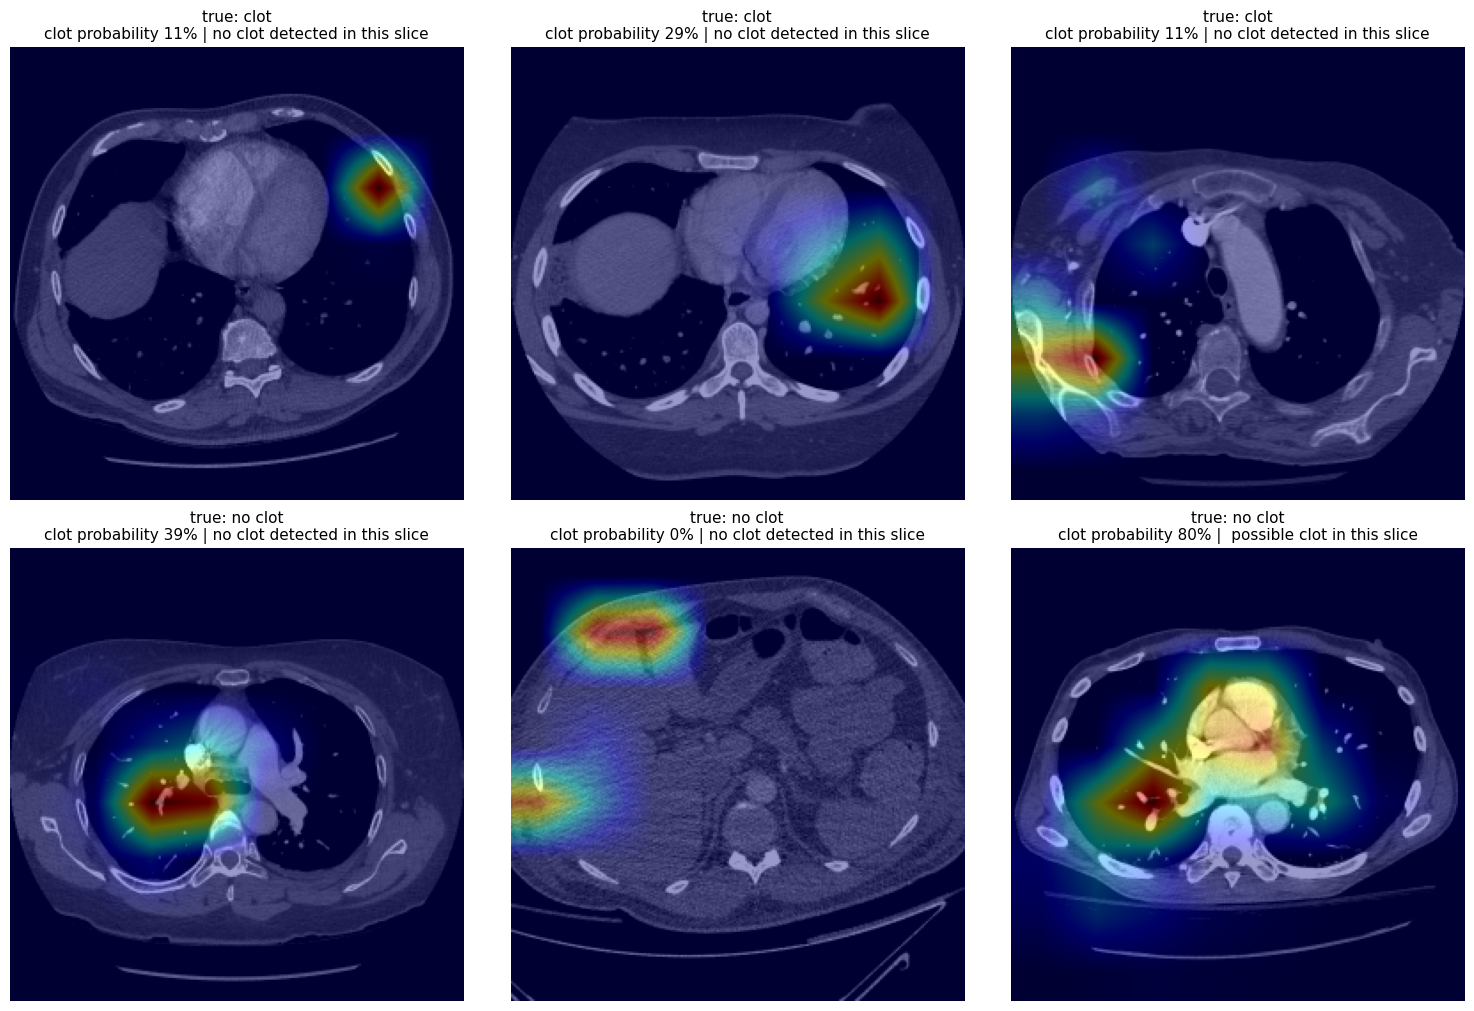

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 10), constrained_layout=True)
for ax, path in zip(axes.ravel(), EXAMPLES):
    overlay, probs, verdict = check(cv2.imread(path, cv2.IMREAD_GRAYSCALE))
    truth = "clot" if os.path.basename(path).startswith("clot") else "no clot"
    ax.imshow(overlay); ax.axis("off")
    ax.set_title(f"true: {truth}\nclot probability {probs['clot']:.0%} | {verdict[2:]}", fontsize=11)
plt.show()

<div style="display:flex;align-items:center;gap:10px;margin:30px 0 4px">
  <div style="background:#0A1A2F;color:#37C5CB;font-weight:800;font-size:15px;padding:7px 14px;border-radius:7px;font-family:Arial">05</div>
  <div style="flex:1">
    <div style="font-size:23px;font-weight:800;color:#0A1A2F;font-family:Arial;line-height:1.2">Camera</div>
    <div style="font-size:14px;color:#5a6b7c;font-family:Arial;margin-top:3px">A separate app that opens the camera only when you run it</div>
  </div>
  <div style="font-family:Arial;font-size:12px;font-weight:700;color:#e0a030;border:1px solid #e0a030;padding:5px 11px;border-radius:20px">OPTIONAL</div><div style="font-family:Arial;font-size:12px;font-weight:700;color:#7b8b99;border:1px solid #dde5e9;padding:5px 11px;border-radius:20px">3 min</div>
</div>
<div style="height:3px;background:linear-gradient(90deg,#37C5CB,rgba(55,197,203,0));margin:10px 0 16px"></div>

<div style="border-left:4px solid #e0a030;background:#FDF7EA;padding:13px 18px;margin:12px 0;border-radius:0 7px 7px 0;font-family:Arial">
<b style="color:#e0a030;font-size:14px">Run this cell only when you want the camera</b>
<ul style="margin:8px 0 0;padding-left:20px;color:#1a2b3c;font-size:14px;line-height:1.7">
  <li style="margin:4px 0">It is a separate app. Nothing above it touches the camera.</li>
  <li style="margin:4px 0">Open the public link in a new tab: the camera usually does not work inside the kaggle preview. The browser asks for permission the first time. Works in Chrome.</li>
  <li style="margin:4px 0">Point the camera at a ct slice on a screen or printout. Expect lower accuracy than uploads: glare, angle and blur were never in the training data.</li>
  <li style="margin:4px 0">To close it, press the stop button on the cell.</li>
</ul>
</div>

In [ ]:
def check_frame(frame, cutoff):
    if frame is None:
        return None, {}, "## Waiting for the camera"
    overlay, probs, verdict = check(frame, cutoff)
    return overlay, probs, f"## {verdict}"

with gr.Blocks(title="PE Live Camera") as camera_app:
    gr.HTML(hero("Live Camera",
                 "Point the camera at a CT slice on a screen or printout. Expect lower accuracy than uploads.",
                 ["EfficientNet-B0", "Updates twice a second", "Not a medical device"]))
    cut_cam = gr.Slider(minimum=0.05, maximum=0.95, value=CUTOFF, step=0.01, label="Cutoff")
    with gr.Row(equal_height=False):
        cam = gr.Image(sources=["webcam"], streaming=True, type="numpy", label="Camera", height=340)
        with gr.Column():
            live_txt = gr.Markdown("## Waiting for the camera", elem_classes="verdict")
            live = gr.Image(type="pil", label="Where the model looked", height=340)
            live_lbl = gr.Label(label="Probabilities", show_label=False)
    cam.stream(check_frame, inputs=[cam, cut_cam], outputs=[live, live_lbl, live_txt], stream_every=0.5)

camera_app.launch(share=True, theme=IOS_THEME, css=IOS_CSS)

<div style="background:linear-gradient(135deg,#0A1A2F,#15757B);padding:24px 28px;border-radius:12px;color:white;font-family:Arial;margin-top:26px">
  <div style="font-size:22px;font-weight:800;margin-bottom:6px">That is the whole pipeline</div>
  <div style="font-size:15px;color:#cfe9ec;line-height:1.6">
    The training notebook built and compared the models. This notebook turns the winner into something anyone can try with one image.
  </div>
</div>